# Project Milestone 2: Dataset and Problem Approval
**Project Title:** Personalized Chess Opening Recommendations Using Machine Learning  
**Team Name:** Machine Learners (Team 66)
---

## 1. Data Source & License

* **Dataset Source:** [Lichess Open Database](https://database.lichess.org/)
* **Dataset Download Link:** [August 2016 Standard Rated Games](https://database.lichess.org/standard/lichess_db_standard_rated_2016-08.pgn.zst)
* **License:** Released into the public domain under the [Creative Commons CC0 1.0 Universal (CC0 1.0) Public Domain Dedication](https://creativecommons.org/publicdomain/zero/1.0/).
* **Usage & Rights:** The CC0 dedication waives all copyright rights worldwide. We have full permission to parse, clean, engineer features, store extracted tabular subsets, and distribute model artifacts for academic and non-commercial research purposes.

---

## 2. Data Card

* **Dataset Overview:** Contains chess game records from 6,483,257 standard rated games played on Lichess.org during August 2016.
* **Key Attributes Extracted:** Player Elo ratings (`WhiteElo`, `BlackElo`), match time control (`TimeControl`), opening identifiers (`ECO`, `Opening`), and game outcome (`Result`).
* **Target Audience & Purpose:** Used to train predictive models that estimate game outcome probabilities, which are then used by our recommendation system to give personalized opening advice to players based on their skill bracket.
* **Data Cleaning & Filtering:** High-cardinality metadata (`White`, `Black`, `Site`, `Event`, `Round`, `UTCTime`) and post-game leakage features (`WhiteRatingDiff`, `BlackRatingDiff`, `WhiteTitle`, `BlackTitle`) are removed prior to training.

---

## 3. Inputs, Outputs, and Task Definition

### Target & Task Definition
* **Machine Learning Task:** Supervised Multi-Class Classification.
* **Target Variable ($Y$):** `result` (Categorical outcome of the game).
  * `1` : White Win
  * `0` : Draw
  * `-1` : Black Win
* **Model Objective:** Estimate the conditional probability distribution $P(Y \mid X)$ across all three potential outcomes given player ratings, match conditions, and opening choices.
* **Downstream Application (Recommendation Engine):** The model takes user query inputs, evaluates candidate openings (`ECO` codes) through the trained classifier, and outputs a ranked list of openings that maximize the user's expected win/draw likelihood for their Elo tier.

### Sample Feature Vector ($X$) & Model Outputs ($Y$)
* **Model Input Feature Vector ($X$):**
  `[avg_elo=1450, elo_diff=35, time_control_class="Rapid", eco_code="C50", opening_draw_rate=0.22]`
* **Model Probabilistic Output ($Y$):**
  `[P(White Win)=0.54, P(Draw)=0.26, P(Black Win)=0.20]`

### User Interface Query Inputs
When a chess player uses the recommendation interface, they do not enter internal model features like `eco_code` or `elo_diff`. Instead, they enter:
1. `user_elo` (e.g., `1400`)
2. `time_control_class` (e.g., `"Rapid"`)
3. `playstyle_preference` (Optional: e.g., `"Tactical"`, `"Aggressive"`, or `"Solid"`)

---

In [147]:
# Chess Reading Tools
!pip install python-chess zstandard -q

### **2.1 Import Dataset + Tools**


In [148]:
import pandas as pd
import chess
import chess.pgn
import zstandard as zstd
import io



# file_path = "lichess_db_standard_rated_2014-08.pgn.zst"
file_path = "lichess_db_standard_rated_2016-08.pgn.zst"

In [149]:
rows = []

with open(file_path, "rb") as f:
    reader = zstd.ZstdDecompressor().stream_reader(f)
    text = io.TextIOWrapper(reader)

    for i in range(100000):
        game = chess.pgn.read_game(text)

        if game is None:
            break

        row = dict(game.headers)

        row["Moves"] = " ".join(
            move.uci() for move in game.mainline_moves()
        )

        rows.append(row)

df = pd.DataFrame(rows)

### **2.2 Data Description**


In [150]:
df.shape

(100000, 20)

In [151]:
df.describe()

,Event,Site,Date,Round,White,Black,Result,UTCDate,UTCTime,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,ECO,Opening,TimeControl,Termination,Moves,WhiteTitle,BlackTitle
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,99911,99911,100000,100000,100000,100000,100000,277,286
unique,99,100000,1,1,23680,23561,4,2,42220,1729,1727,583,545,452,2102,358,4,98962,6,6
top,Rated Blitz game,https://lichess.org/Rd5bcqt7,????.??.??,?,NimzoBros,NimzoBros,1-0,2016.08.01,12:00:02,1500,1500,+9,-10,A00,Van't Kruijs Opening,300+0,Normal,,FM,LM
freq,37712,1,100000,100000,181,182,49669,83047,51,774,532,4476,4429,6382,1845,17819,68053,367,99,96


In [152]:
df.isnull().sum()

Event                  0
Site                   0
Date                   0
Round                  0
White                  0
Black                  0
Result                 0
UTCDate                0
UTCTime                0
WhiteElo               0
BlackElo               0
WhiteRatingDiff       89
BlackRatingDiff       89
ECO                    0
Opening                0
TimeControl            0
Termination            0
Moves                  0
WhiteTitle         99723
BlackTitle         99714
dtype: int64

In [153]:
df[["ECO", "Opening"]].head(20)

,ECO,Opening
0,?,?
1,B00,King's Pawn
2,B00,"St. George Defense: New St. George, Three Pawn..."
3,C53,"Italian Game: Classical Variation, Albin Gambit"
4,E90,King's Indian Defense: Larsen Variation
5,A46,Torre Attack #2
6,D15,Slav Defense: Three Knights Variation
7,B06,Modern Defense: Two Knights Variation
8,B30,Sicilian Defense: Old Sicilian
9,A40,Englund Gambit Complex: Hartlaub-Charlick Gambit


In [154]:
df["ECO"].value_counts()

ECO
A00    6382
C00    4719
B01    4621
A40    4515
D00    3567
       ... 
C04       1
E39       1
D76       1
C73       1
D84       1
Name: count, Length: 452, dtype: int64

In [155]:
df["Event"].value_counts().head(10)

Event
Rated Blitz game                                                      37712
Rated Classical game                                                  23661
Rated Bullet game                                                     19116
Rated Blitz tournament https://lichess.org/tournament/dtU8q3T1          662
Rated Classical tournament https://lichess.org/tournament/LGcu43Jf      604
Rated Classical tournament https://lichess.org/tournament/jMo5y2hz      532
Rated Blitz tournament https://lichess.org/tournament/EAsChEx0          491
Rated Classical tournament https://lichess.org/tournament/7bMCu7ds      470
Rated Bullet tournament https://lichess.org/tournament/qP8wYMWG         458
Rated Correspondence game                                               431
Name: count, dtype: int64

In [156]:
# Result distribution
df["Result"].value_counts()

Result
1-0        49669
0-1        46397
1/2-1/2     3904
*             30
Name: count, dtype: int64

In [157]:
# Elo Distribution
df[["WhiteElo", "BlackElo"]].describe()

,WhiteElo,BlackElo
count,100000,100000
unique,1729,1727
top,1500,1500
freq,774,532


In [158]:
# Top Openings
df["ECO"].value_counts().head(15)

ECO
A00    6382
C00    4719
B01    4621
A40    4515
D00    3567
B00    3383
C41    3082
C20    2628
B20    2370
B07    2023
D02    1974
B06    1832
A04    1693
C50    1599
C40    1530
Name: count, dtype: int64

In [159]:
# Time Controls
df["TimeControl"].value_counts().head(15)

TimeControl
300+0    17819
180+0    16455
60+0     14411
600+0     9903
30+0      4216
120+0     3247
180+2     2479
900+0     2379
300+5     1771
480+0     1557
300+8     1362
120+1     1180
240+0     1077
420+0     1001
300+2      945
Name: count, dtype: int64

### **2.3 Data Cleaning**

#### **Dropped Fields:**
- Site
- Date
- Round
- White
- Black
- UTCTime
- WhiteRatingDiff
- BlackRatingDiff
- WhiteTitle
- BlackTitle

#### **Persistent Fields:**
1.   Event
2.   Result - W/L for who
3.   BlackElo
4.   ECO
5.   *Opening
6.   TimeControl (420 + 8 = 420s per player + 8s per turn)
7.   Termination
8.   Moves

***Note:** Opening and ECO represent the same thing, opening can be more accurate in some instances but is less consistent than ECO



In [160]:
# Make sure Elo values are numeric
df["WhiteElo"] = pd.to_numeric(df["WhiteElo"], errors="coerce")
df["BlackElo"] = pd.to_numeric(df["BlackElo"], errors="coerce")

# Elo difference is always a whole number
df["EloDiff"] = (df["WhiteElo"] - df["BlackElo"]).astype("Int64")

# Create combined Elo features
df["AverageElo"] = (df["WhiteElo"] + df["BlackElo"]) / 2

df.head()

,Event,Site,Date,Round,White,Black,Result,UTCDate,UTCTime,WhiteElo,...,BlackRatingDiff,ECO,Opening,TimeControl,Termination,Moves,WhiteTitle,BlackTitle,EloDiff,AverageElo
0,Rated Bullet tournament https://lichess.org/to...,https://lichess.org/Rd5bcqt7,????.??.??,?,dojocleaninh,jclp1102,0-1,2016.07.31,22:00:02,1801,...,+11,?,?,60+0,Abandoned,,NaN,NaN,-12,1807.0
1,Rated Blitz tournament https://lichess.org/tou...,https://lichess.org/1Bub1MPg,????.??.??,?,rapa4,chesspasky,1-0,2016.07.31,22:00:02,1500,...,-9,B00,King's Pawn,300+0,Abandoned,e2e4,NaN,NaN,24,1488.0
2,Rated Blitz tournament https://lichess.org/tou...,https://lichess.org/qgr9F6wh,????.??.??,?,Tr0n,chedly,0-1,2016.07.31,22:00:02,1261,...,+10,B00,"St. George Defense: New St. George, Three Pawn...",300+0,Normal,d2d4 e7e6 c2c4 a7a6 e2e4 c7c5 f1d3 c5d4 g1f3 f...,NaN,NaN,-84,1303.0
3,Rated Bullet game,https://lichess.org/boaxG6qw,????.??.??,?,capateam,keedt,0-1,2016.07.31,22:00:00,1744,...,+7,C53,"Italian Game: Classical Variation, Albin Gambit",120+1,Time forfeit,e2e4 e7e5 g1f3 b8c6 f1c4 f8c5 c2c3 g8f6 e1g1 d...,NaN,NaN,-104,1796.0
4,Rated Bullet tournament https://lichess.org/to...,https://lichess.org/VKb4KGcd,????.??.??,?,JuanCamilo9506,swingkyd,1-0,2016.07.31,22:00:02,1485,...,-12,E90,King's Indian Defense: Larsen Variation,60+0,Time forfeit,d2d4 g8f6 c2c4 g7g6 b1c3 f8g7 g1f3 d7d6 e2e4 e...,NaN,NaN,14,1478.0


In [162]:
columns_to_drop = [
    "Site",
    "Date",
    "Round",
    "White",
    "Black",
    "UTCDate",
    "WhiteElo",
    "BlackElo",
    "UTCTime",
    "WhiteRatingDiff",
    "BlackRatingDiff",
    "WhiteTitle",
    "BlackTitle",
]

dfclean = df.drop(columns=columns_to_drop)

dfclean.head()

,Event,Result,ECO,Opening,TimeControl,Termination,Moves,EloDiff,AverageElo
0,Rated Bullet tournament https://lichess.org/to...,0-1,?,?,60+0,Abandoned,,-12,1807.0
1,Rated Blitz tournament https://lichess.org/tou...,1-0,B00,King's Pawn,300+0,Abandoned,e2e4,24,1488.0
2,Rated Blitz tournament https://lichess.org/tou...,0-1,B00,"St. George Defense: New St. George, Three Pawn...",300+0,Normal,d2d4 e7e6 c2c4 a7a6 e2e4 c7c5 f1d3 c5d4 g1f3 f...,-84,1303.0
3,Rated Bullet game,0-1,C53,"Italian Game: Classical Variation, Albin Gambit",120+1,Time forfeit,e2e4 e7e5 g1f3 b8c6 f1c4 f8c5 c2c3 g8f6 e1g1 d...,-104,1796.0
4,Rated Bullet tournament https://lichess.org/to...,1-0,E90,King's Indian Defense: Larsen Variation,60+0,Time forfeit,d2d4 g8f6 c2c4 g7g6 b1c3 f8g7 g1f3 d7d6 e2e4 e...,14,1478.0


In [163]:
# Count the number moves
dfclean["PlyCount"] = dfclean["Moves"].str.split().str.len()
dfclean.head()

,Event,Result,ECO,Opening,TimeControl,Termination,Moves,EloDiff,AverageElo,PlyCount
0,Rated Bullet tournament https://lichess.org/to...,0-1,?,?,60+0,Abandoned,,-12,1807.0,0
1,Rated Blitz tournament https://lichess.org/tou...,1-0,B00,King's Pawn,300+0,Abandoned,e2e4,24,1488.0,1
2,Rated Blitz tournament https://lichess.org/tou...,0-1,B00,"St. George Defense: New St. George, Three Pawn...",300+0,Normal,d2d4 e7e6 c2c4 a7a6 e2e4 c7c5 f1d3 c5d4 g1f3 f...,-84,1303.0,58
3,Rated Bullet game,0-1,C53,"Italian Game: Classical Variation, Albin Gambit",120+1,Time forfeit,e2e4 e7e5 g1f3 b8c6 f1c4 f8c5 c2c3 g8f6 e1g1 d...,-104,1796.0,36
4,Rated Bullet tournament https://lichess.org/to...,1-0,E90,King's Indian Defense: Larsen Variation,60+0,Time forfeit,d2d4 g8f6 c2c4 g7g6 b1c3 f8g7 g1f3 d7d6 e2e4 e...,14,1478.0,59


In [164]:
dfclean["Termination"].value_counts()

Termination
Normal              68053
Time forfeit        31344
Abandoned             600
Rules infraction        3
Name: count, dtype: int64

In [165]:
# Drop Rules Infraction/Abandoned Games
dfclean = dfclean[
    ~dfclean["Termination"].isin([
        "Abandoned",
        "Rules infraction"
    ])
]

# Keep only games with a completed valid result
dfclean = dfclean[
    dfclean["Result"].isin(["1-0", "0-1", "1/2-1/2"])
]


dfclean["Termination"].value_counts()

Termination
Normal          68053
Time forfeit    31344
Name: count, dtype: int64

In [166]:
dfclean.head(10)

,Event,Result,ECO,Opening,TimeControl,Termination,Moves,EloDiff,AverageElo,PlyCount
2,Rated Blitz tournament https://lichess.org/tou...,0-1,B00,"St. George Defense: New St. George, Three Pawn...",300+0,Normal,d2d4 e7e6 c2c4 a7a6 e2e4 c7c5 f1d3 c5d4 g1f3 f...,-84,1303.0,58
3,Rated Bullet game,0-1,C53,"Italian Game: Classical Variation, Albin Gambit",120+1,Time forfeit,e2e4 e7e5 g1f3 b8c6 f1c4 f8c5 c2c3 g8f6 e1g1 d...,-104,1796.0,36
4,Rated Bullet tournament https://lichess.org/to...,1-0,E90,King's Indian Defense: Larsen Variation,60+0,Time forfeit,d2d4 g8f6 c2c4 g7g6 b1c3 f8g7 g1f3 d7d6 e2e4 e...,14,1478.0,59
5,Rated Bullet tournament https://lichess.org/to...,0-1,A46,Torre Attack #2,60+0,Normal,d2d4 g8f6 g1f3 e7e6 g2g3 b7b6 f1g2 c8b7 e1g1 d...,-25,2119.5,110
6,Rated Blitz tournament https://lichess.org/tou...,1-0,D15,Slav Defense: Three Knights Variation,300+0,Normal,d2d4 d7d5 c2c4 c7c6 b1c3 g8f6 g1f3 c8f5 c1g5 h...,73,1561.5,91
7,Rated Bullet tournament https://lichess.org/to...,0-1,B06,Modern Defense: Two Knights Variation,60+0,Normal,e2e4 g7g6 d2d4 f8g7 b1c3 d7d6 g1f3 b8d7 f1d3 g...,-34,1886.0,52
8,Rated Blitz tournament https://lichess.org/tou...,0-1,B30,Sicilian Defense: Old Sicilian,300+0,Normal,e2e4 c7c5 g1f3 b8c6 f1d3 g8f6 b1c3 d7d6 e1g1 g...,-6,1503.0,34
9,Rated Bullet game,0-1,A40,Englund Gambit Complex: Hartlaub-Charlick Gambit,30+0,Time forfeit,d2d4 e7e5 d4e5 d7d6 g1f3 b8c6 e5d6 f8d6 c1g5 g...,-83,2212.5,72
10,Rated Blitz tournament https://lichess.org/tou...,0-1,D00,Queen's Pawn Game #2,300+0,Normal,d2d4 d7d5 e2e3 c8f5 g1f3 f5g4 f1e2 e7e6 e1g1 g...,34,1402.0,46
11,Rated Bullet tournament https://lichess.org/to...,1-0,A15,English Opening: Anglo-Indian Defense,60+0,Normal,c2c4 g8f6 g2g3 e7e5 f1g2 c7c6 b1c3 f8b4 a2a3 b...,15,1978.5,99


In [167]:
dfclean.describe()

,EloDiff,AverageElo,PlyCount
count,99397.0,99397.000000,99397.000000
mean,1.367446,1736.360071,67.514613
std,200.470524,243.012952,30.942594
min,-1129.0,879.000000,0.000000
25%,-104.0,1568.000000,46.000000
50%,1.0,1732.500000,64.000000
75%,106.0,1897.500000,86.000000
max,1302.0,2656.000000,287.000000


#### **2.4 Plots/Distributions**

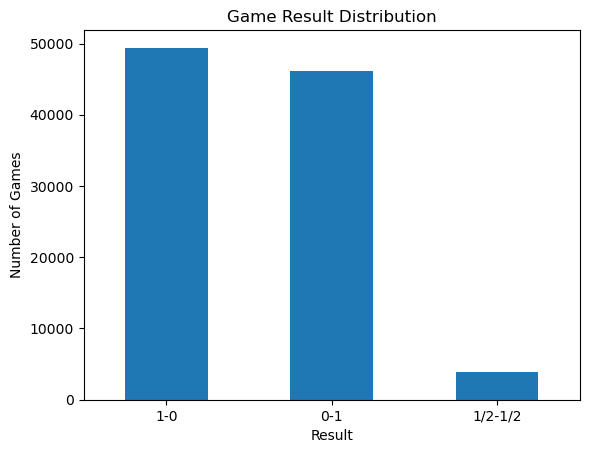

In [169]:
import matplotlib.pyplot as plt

dfclean["Result"].value_counts().plot(kind="bar")

plt.title("Game Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Games")
plt.xticks(rotation=0)
plt.show()

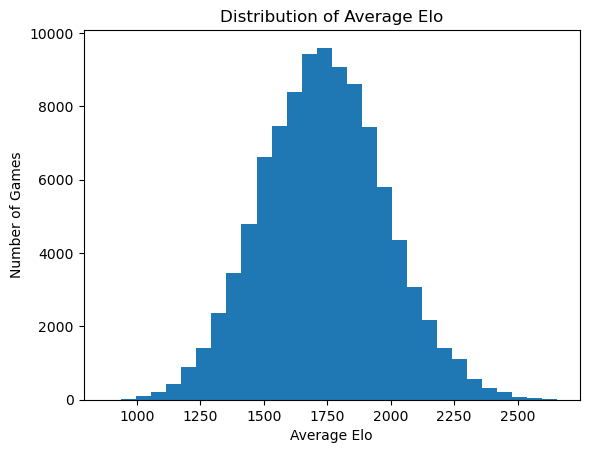

In [170]:
dfclean["AverageElo"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Average Elo")
plt.xlabel("Average Elo")
plt.ylabel("Number of Games")
plt.show()

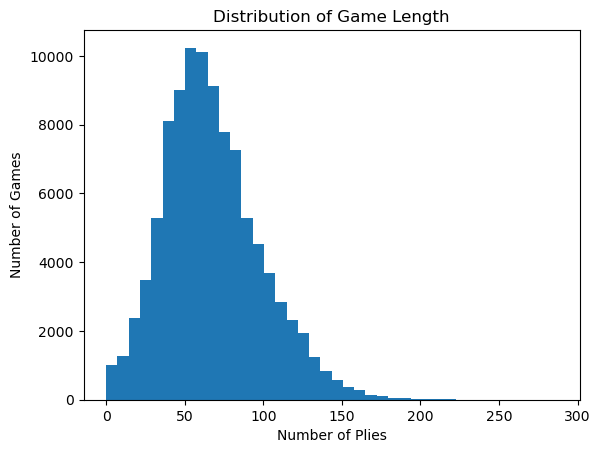

In [172]:
dfclean["PlyCount"].plot(
    kind="hist",
    bins=40
)

plt.title("Distribution of Game Length")
plt.xlabel("Number of Plies")
plt.ylabel("Number of Games")
plt.show()

In [177]:
# Absolute size of the Elo difference
dfclean["RatingGap"] = dfclean["EloDiff"].abs()

# Lower-rated player won
dfclean["Upset"] = (
    ((dfclean["EloDiff"] < 0) & (dfclean["Result"] == "1-0")) |
    ((dfclean["EloDiff"] > 0) & (dfclean["Result"] == "0-1"))
)

# Rating Gap Significance Groups
dfclean["RatingGapGroup"] = pd.cut(
    dfclean["RatingGap"],
    bins=[0, 50, 100, 200, 300, 500, float("inf")],
    labels=[
        "0-49",
        "50-99",
        "100-199",
        "200-299",
        "300-499",
        "500+"
    ],
    include_lowest=True
)

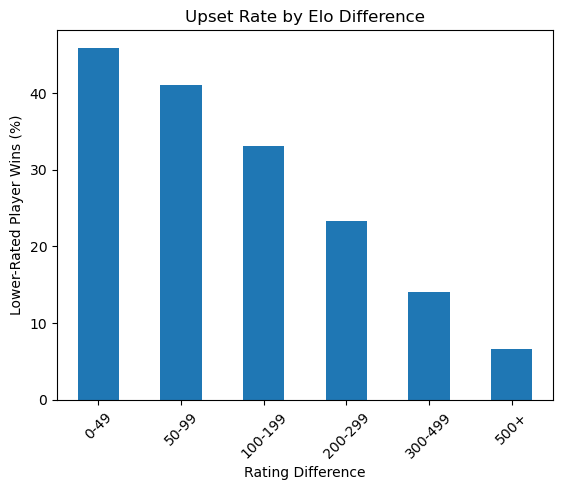

In [178]:
# Keep only decisive results
decisive_games = dfclean[
    dfclean["Result"].isin(["1-0", "0-1"])
]


upset_rates = (
    decisive_games
    .groupby("RatingGapGroup", observed=True)["Upset"]
    .mean() * 100
)

upset_rates # Underdog win rate by rating gap

upset_rates.plot(kind="bar")
plt.title("Upset Rate by Elo Difference")
plt.xlabel("Rating Difference")
plt.ylabel("Lower-Rated Player Wins (%)")
plt.xticks(rotation=45)
plt.show()